### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "PSO"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "BERT"
DATASET_NAME = "TCP"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
#from flaml import AutoML
import joblib

### Version Checking

In [2]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [3]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 26 18:34:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   36C    P8             13W /  300W |   48336MiB /  49140MiB |      5%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [3]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Entries,Unique_C-COMM,Python_Related_Process,State_Transition,Local_IP_Address_Access,Remote_IP_Address_Access,Local_Port_Access,Remote_Port_Access,Level
0,10Cent10-999.0.4.tar.gz,946,7,316,"{'FIN_WAIT1 -> ->': 188, 'SYN_SENT -> ->': 187...",2,62,194,21,1
1,10Cent11-999.0.4.tar.gz,874,6,301,"{'SYN_SENT -> ->': 177, 'FIN_WAIT1 -> ->': 170...",2,51,181,18,1
2,11Cent-999.0.0.tar.gz,801,4,272,"{'FIN_WAIT1 -> ->': 160, 'SYN_SENT -> ->': 157...",2,52,164,17,1
3,11Cent-999.0.1.tar.gz,728,4,254,"{'SYN_SENT -> ->': 149, 'FIN_WAIT1 -> ->': 141...",2,39,152,14,1
4,11Cent-999.0.2.tar.gz,655,4,234,"{'SYN_SENT -> ->': 133, 'FIN_WAIT1 -> ->': 128...",2,32,135,11,1


### Clear Backend Session

In [4]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [4]:
selected_features = ['Total_Entries', 'Python_Related_Process', 'Local_IP_Address_Access', 'Local_Port_Access', 'Remote_Port_Access']

### Data Preprocessing

In [5]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 5)
Validation set shape   : (2141, 5)
Test set shape         : (2141, 5)


### Setup OUTPUT_DIR

In [6]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_TCP_PSO_Attention_BERT'

### Model

In [7]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)

# ==========================
# Load TensorFlow-compatible BERT tokenizer
# ==========================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

max_len = 34

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")
val_enc   = tokenizer(val_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")
test_enc  = tokenizer(test_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")


# ==========================
# Labels
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_NAME,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)


# ==========================
# Load TensorFlow BERT
# ==========================
bert = TFBertModel.from_pretrained("bert-base-uncased", from_pt=False)

# ==========================
# Build TensorFlow classification model
# ==========================
input_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

bert_outputs = bert(input_ids, attention_mask=attention_mask)
cls_token = bert_outputs.last_hidden_state[:, 0, :]  # CLS token

x = tf.keras.layers.Dense(128, activation="relu")(cls_token)
x = tf.keras.layers.Dropout(0.3)(x)

output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output_layer)


# ==========================
# Compile model
# ==========================
model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Some layers from the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 34)]         0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 34)]         0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  109482240   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 34,                                            

### Compime the Model

In [8]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    {"input_ids": train_enc["input_ids"], "attention_mask": train_enc["attention_mask"]},
    y_train,
    validation_data=(
        {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
        y_val
    ),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.7064 - accuracy: 0.4993
Epoch 1: val_accuracy improved from -inf to 0.49930, saving model to Evaluation_Outputs_TCP_PSO_Attention_BERT\Evaluation_Outputs_TCP_PSO_Attention_BERT.h5
625/625 [==============================] - 87s 112ms/step - loss: 0.7064 - accuracy: 0.4993 - val_loss: 0.6932 - val_accuracy: 0.4993 - lr: 2.0000e-05
Epoch 2/200
625/625 [==============================] - ETA: 0s - loss: 0.6953 - accuracy: 0.5050
Epoch 2: val_accuracy improved from 0.49930 to 0.50070, saving model to Evaluation_Outputs_TCP_PSO_Attention_BERT\Evaluation_Outputs_TCP_PSO_Attention_BERT.h5
625/625 [==============================] - 73s 117ms/step - loss: 0.6953 - accuracy: 0.5050 - val_loss: 0.6984 - val_accuracy: 0.5007 - lr: 2.0000e-05
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.6930 - accuracy: 0.5159
Epoch 3: val_accuracy did not improve from 0.50070
625/625 [==============================] 

Epoch 23/200
625/625 [==============================] - ETA: 0s - loss: 0.2277 - accuracy: 0.8986
Epoch 23: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 97ms/step - loss: 0.2277 - accuracy: 0.8986 - val_loss: 0.7426 - val_accuracy: 0.7567 - lr: 2.0000e-05
Epoch 24/200
625/625 [==============================] - ETA: 0s - loss: 0.2154 - accuracy: 0.9023
Epoch 24: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.2154 - accuracy: 0.9023 - val_loss: 0.7974 - val_accuracy: 0.7562 - lr: 2.0000e-05
Epoch 25/200
625/625 [==============================] - ETA: 0s - loss: 0.1988 - accuracy: 0.9084
Epoch 25: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.1988 - accuracy: 0.9084 - val_loss: 0.9067 - val_accuracy: 0.7496 - lr: 2.0000e-05
Epoch 26/200
625/625 [==============================] - ETA: 0s - loss: 0.1950 - accuracy: 0.9113
Ep

625/625 [==============================] - ETA: 0s - loss: 0.1149 - accuracy: 0.9476
Epoch 50: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.1149 - accuracy: 0.9476 - val_loss: 1.1228 - val_accuracy: 0.7412 - lr: 2.0000e-05
Epoch 51/200
625/625 [==============================] - ETA: 0s - loss: 0.1066 - accuracy: 0.9513
Epoch 51: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.1066 - accuracy: 0.9513 - val_loss: 0.9589 - val_accuracy: 0.7567 - lr: 2.0000e-05
Epoch 52/200
625/625 [==============================] - ETA: 0s - loss: 0.1129 - accuracy: 0.9508
Epoch 52: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.1129 - accuracy: 0.9508 - val_loss: 1.1021 - val_accuracy: 0.7562 - lr: 2.0000e-05
Epoch 53/200
625/625 [==============================] - ETA: 0s - loss: 0.1106 - accuracy: 0.9522
Epoch 53: val_a

625/625 [==============================] - 60s 96ms/step - loss: 0.0908 - accuracy: 0.9577 - val_loss: 1.3683 - val_accuracy: 0.7412 - lr: 2.0000e-05
Epoch 78/200
625/625 [==============================] - ETA: 0s - loss: 0.0876 - accuracy: 0.9580
Epoch 78: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0876 - accuracy: 0.9580 - val_loss: 1.1869 - val_accuracy: 0.7422 - lr: 2.0000e-05
Epoch 79/200
625/625 [==============================] - ETA: 0s - loss: 0.0816 - accuracy: 0.9615
Epoch 79: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0816 - accuracy: 0.9615 - val_loss: 1.4650 - val_accuracy: 0.7408 - lr: 2.0000e-05
Epoch 80/200
625/625 [==============================] - ETA: 0s - loss: 0.0860 - accuracy: 0.9592
Epoch 80: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0860 - accuracy: 0.9592 - val_los

Epoch 105/200
625/625 [==============================] - ETA: 0s - loss: 0.0974 - accuracy: 0.9591
Epoch 105: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0974 - accuracy: 0.9591 - val_loss: 1.1234 - val_accuracy: 0.7403 - lr: 2.0000e-05
Epoch 106/200
625/625 [==============================] - ETA: 0s - loss: 0.0997 - accuracy: 0.9564
Epoch 106: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0997 - accuracy: 0.9564 - val_loss: 1.0732 - val_accuracy: 0.7356 - lr: 2.0000e-05
Epoch 107/200
625/625 [==============================] - ETA: 0s - loss: 0.0819 - accuracy: 0.9625
Epoch 107: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0819 - accuracy: 0.9625 - val_loss: 1.4075 - val_accuracy: 0.7436 - lr: 2.0000e-05
Epoch 108/200
625/625 [==============================] - ETA: 0s - loss: 0.0802 - accuracy: 0.

625/625 [==============================] - ETA: 0s - loss: 0.0727 - accuracy: 0.9638
Epoch 132: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0727 - accuracy: 0.9638 - val_loss: 1.3247 - val_accuracy: 0.7482 - lr: 2.0000e-05
Epoch 133/200
625/625 [==============================] - ETA: 0s - loss: 0.0749 - accuracy: 0.9634
Epoch 133: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0749 - accuracy: 0.9634 - val_loss: 1.5063 - val_accuracy: 0.7440 - lr: 2.0000e-05
Epoch 134/200
625/625 [==============================] - ETA: 0s - loss: 0.0876 - accuracy: 0.9609
Epoch 134: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0876 - accuracy: 0.9609 - val_loss: 1.2753 - val_accuracy: 0.7408 - lr: 2.0000e-05
Epoch 135/200
625/625 [==============================] - ETA: 0s - loss: 0.0786 - accuracy: 0.9639
Epoch 135

625/625 [==============================] - ETA: 0s - loss: 0.0750 - accuracy: 0.9640
Epoch 159: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0750 - accuracy: 0.9640 - val_loss: 1.4014 - val_accuracy: 0.7426 - lr: 2.0000e-05
Epoch 160/200
625/625 [==============================] - ETA: 0s - loss: 0.0768 - accuracy: 0.9642
Epoch 160: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0768 - accuracy: 0.9642 - val_loss: 1.3415 - val_accuracy: 0.7440 - lr: 2.0000e-05
Epoch 161/200
625/625 [==============================] - ETA: 0s - loss: 0.0790 - accuracy: 0.9638
Epoch 161: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0790 - accuracy: 0.9638 - val_loss: 1.4308 - val_accuracy: 0.7459 - lr: 2.0000e-05
Epoch 162/200
625/625 [==============================] - ETA: 0s - loss: 0.0825 - accuracy: 0.9614
Epoch 162

625/625 [==============================] - ETA: 0s - loss: 0.0914 - accuracy: 0.9600
Epoch 186: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.0914 - accuracy: 0.9600 - val_loss: 1.2429 - val_accuracy: 0.7333 - lr: 2.0000e-05
Epoch 187/200
625/625 [==============================] - ETA: 0s - loss: 0.2916 - accuracy: 0.8852
Epoch 187: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.2916 - accuracy: 0.8852 - val_loss: 0.8047 - val_accuracy: 0.7361 - lr: 2.0000e-05
Epoch 188/200
625/625 [==============================] - ETA: 0s - loss: 0.2224 - accuracy: 0.9219
Epoch 188: val_accuracy did not improve from 0.76787
625/625 [==============================] - 60s 96ms/step - loss: 0.2224 - accuracy: 0.9219 - val_loss: 0.9317 - val_accuracy: 0.7380 - lr: 2.0000e-05
Epoch 189/200
625/625 [==============================] - ETA: 0s - loss: 0.1489 - accuracy: 0.9400
Epoch 189

### Clear Backend Session

In [9]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [10]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    {"input_ids": test_enc["input_ids"], "attention_mask": test_enc["attention_mask"]},
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 12089.26 seconds
Validation Time: 4.21 seconds
Testing Time: 2.83 seconds

Validation Accuracy: 0.7319
Test Accuracy: 0.7604


### Save Training Log

In [11]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_TCP_PSO_Attention_BERT\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.706415,0.499349,0.693155,0.499299,0.00002
1,2,0.695329,0.504955,0.698354,0.500701,0.00002
2,3,0.693011,0.515867,0.698216,0.499299,0.00002
3,4,0.667512,0.576334,0.607718,0.679589,0.00002
4,5,0.601272,0.673941,0.567044,0.695937,0.00002


### Trainig and Validation Plot

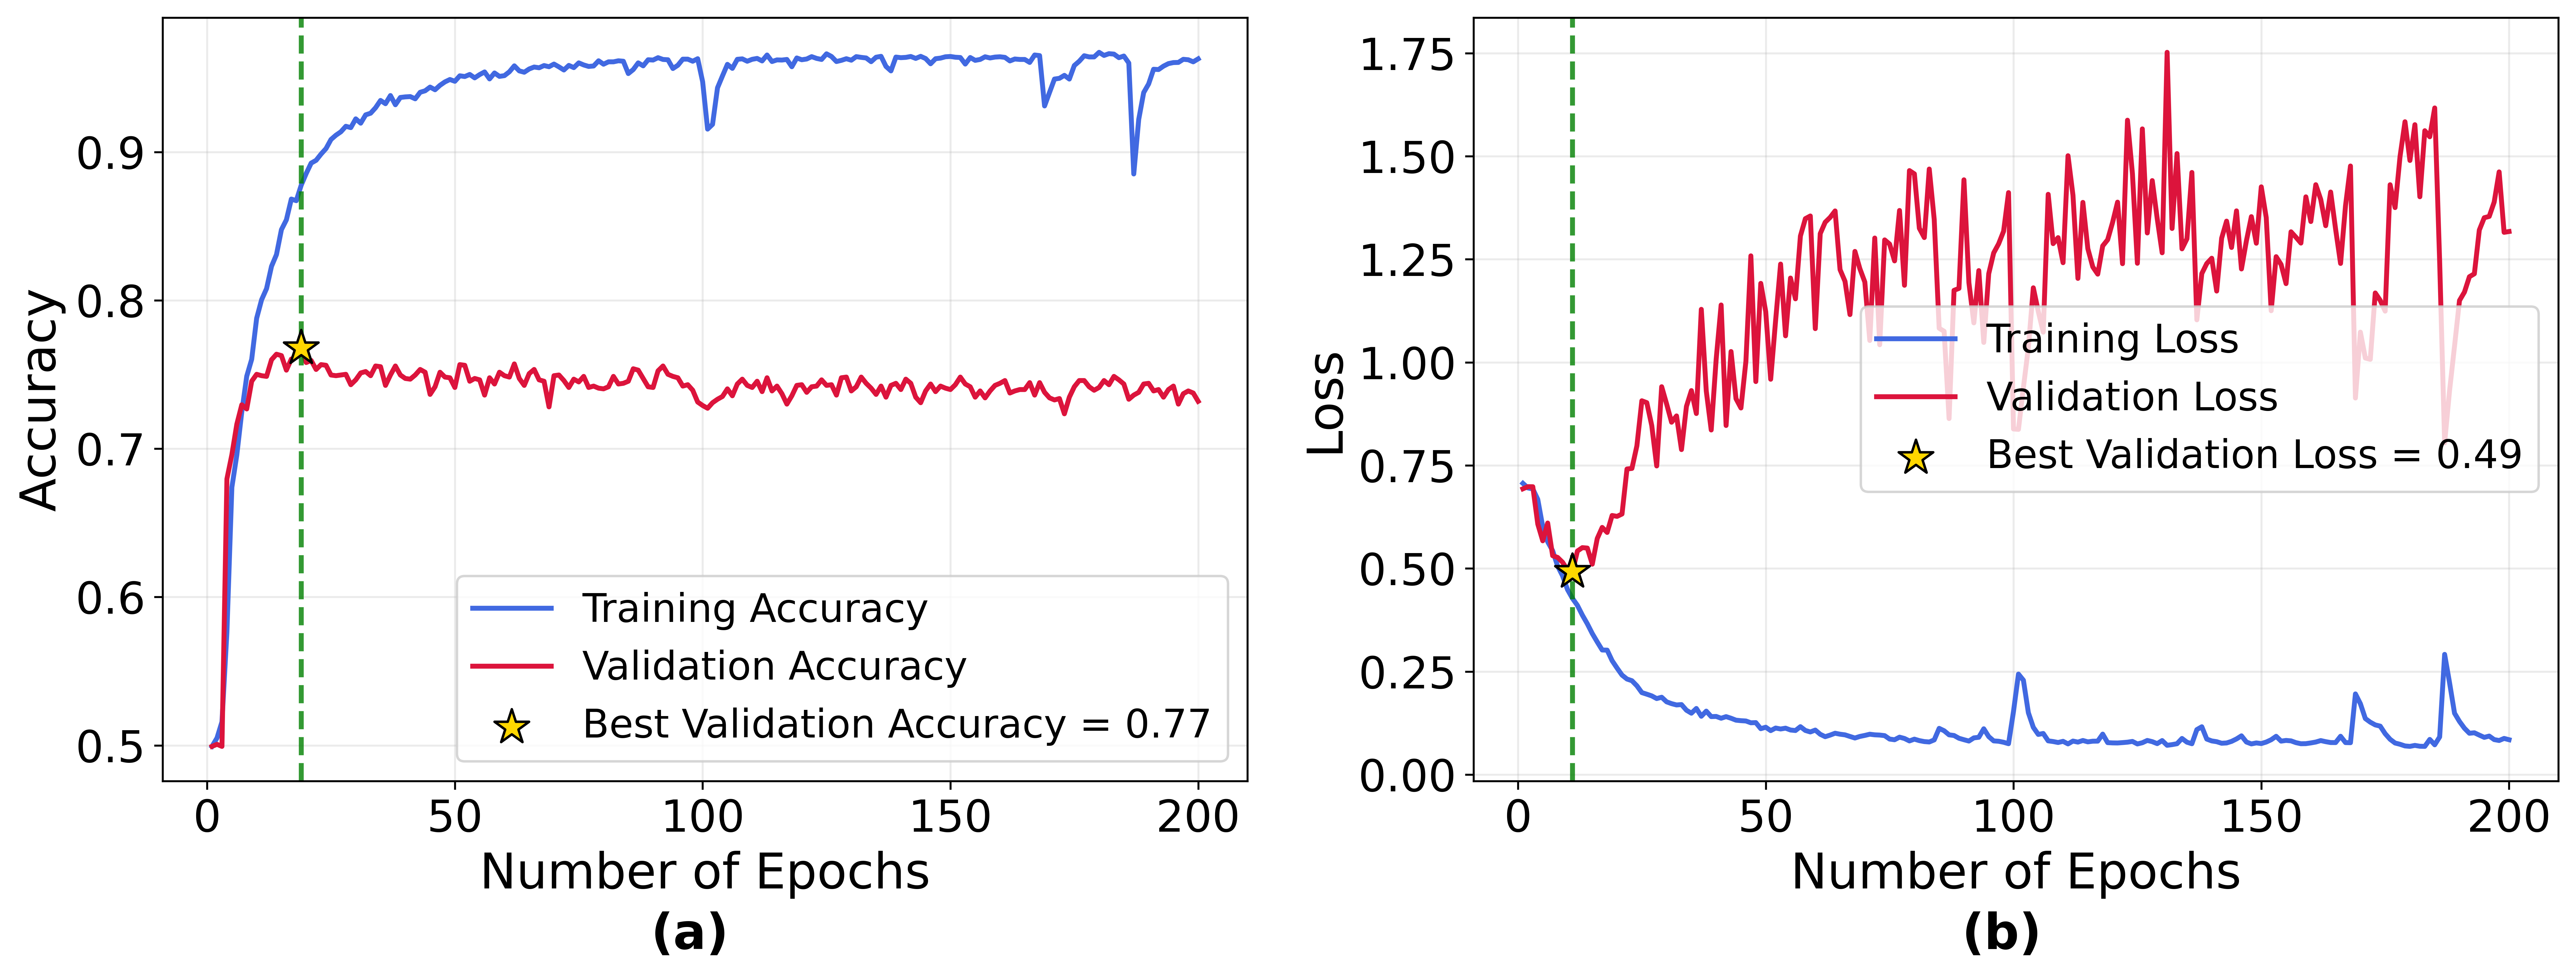

In [12]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.967564
Precision : 0.963810
Recall    : 0.971537
F1-score  : 0.967658
ROC AUC   : 0.995524
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.971371  0.963600  0.967470      5000
         1.0   0.963810  0.971537  0.967658      4989

    accuracy                       0.967564      9989
   macro avg   0.967590  0.967569  0.967564      9989
weighted avg   0.967595  0.967564  0.967564      9989



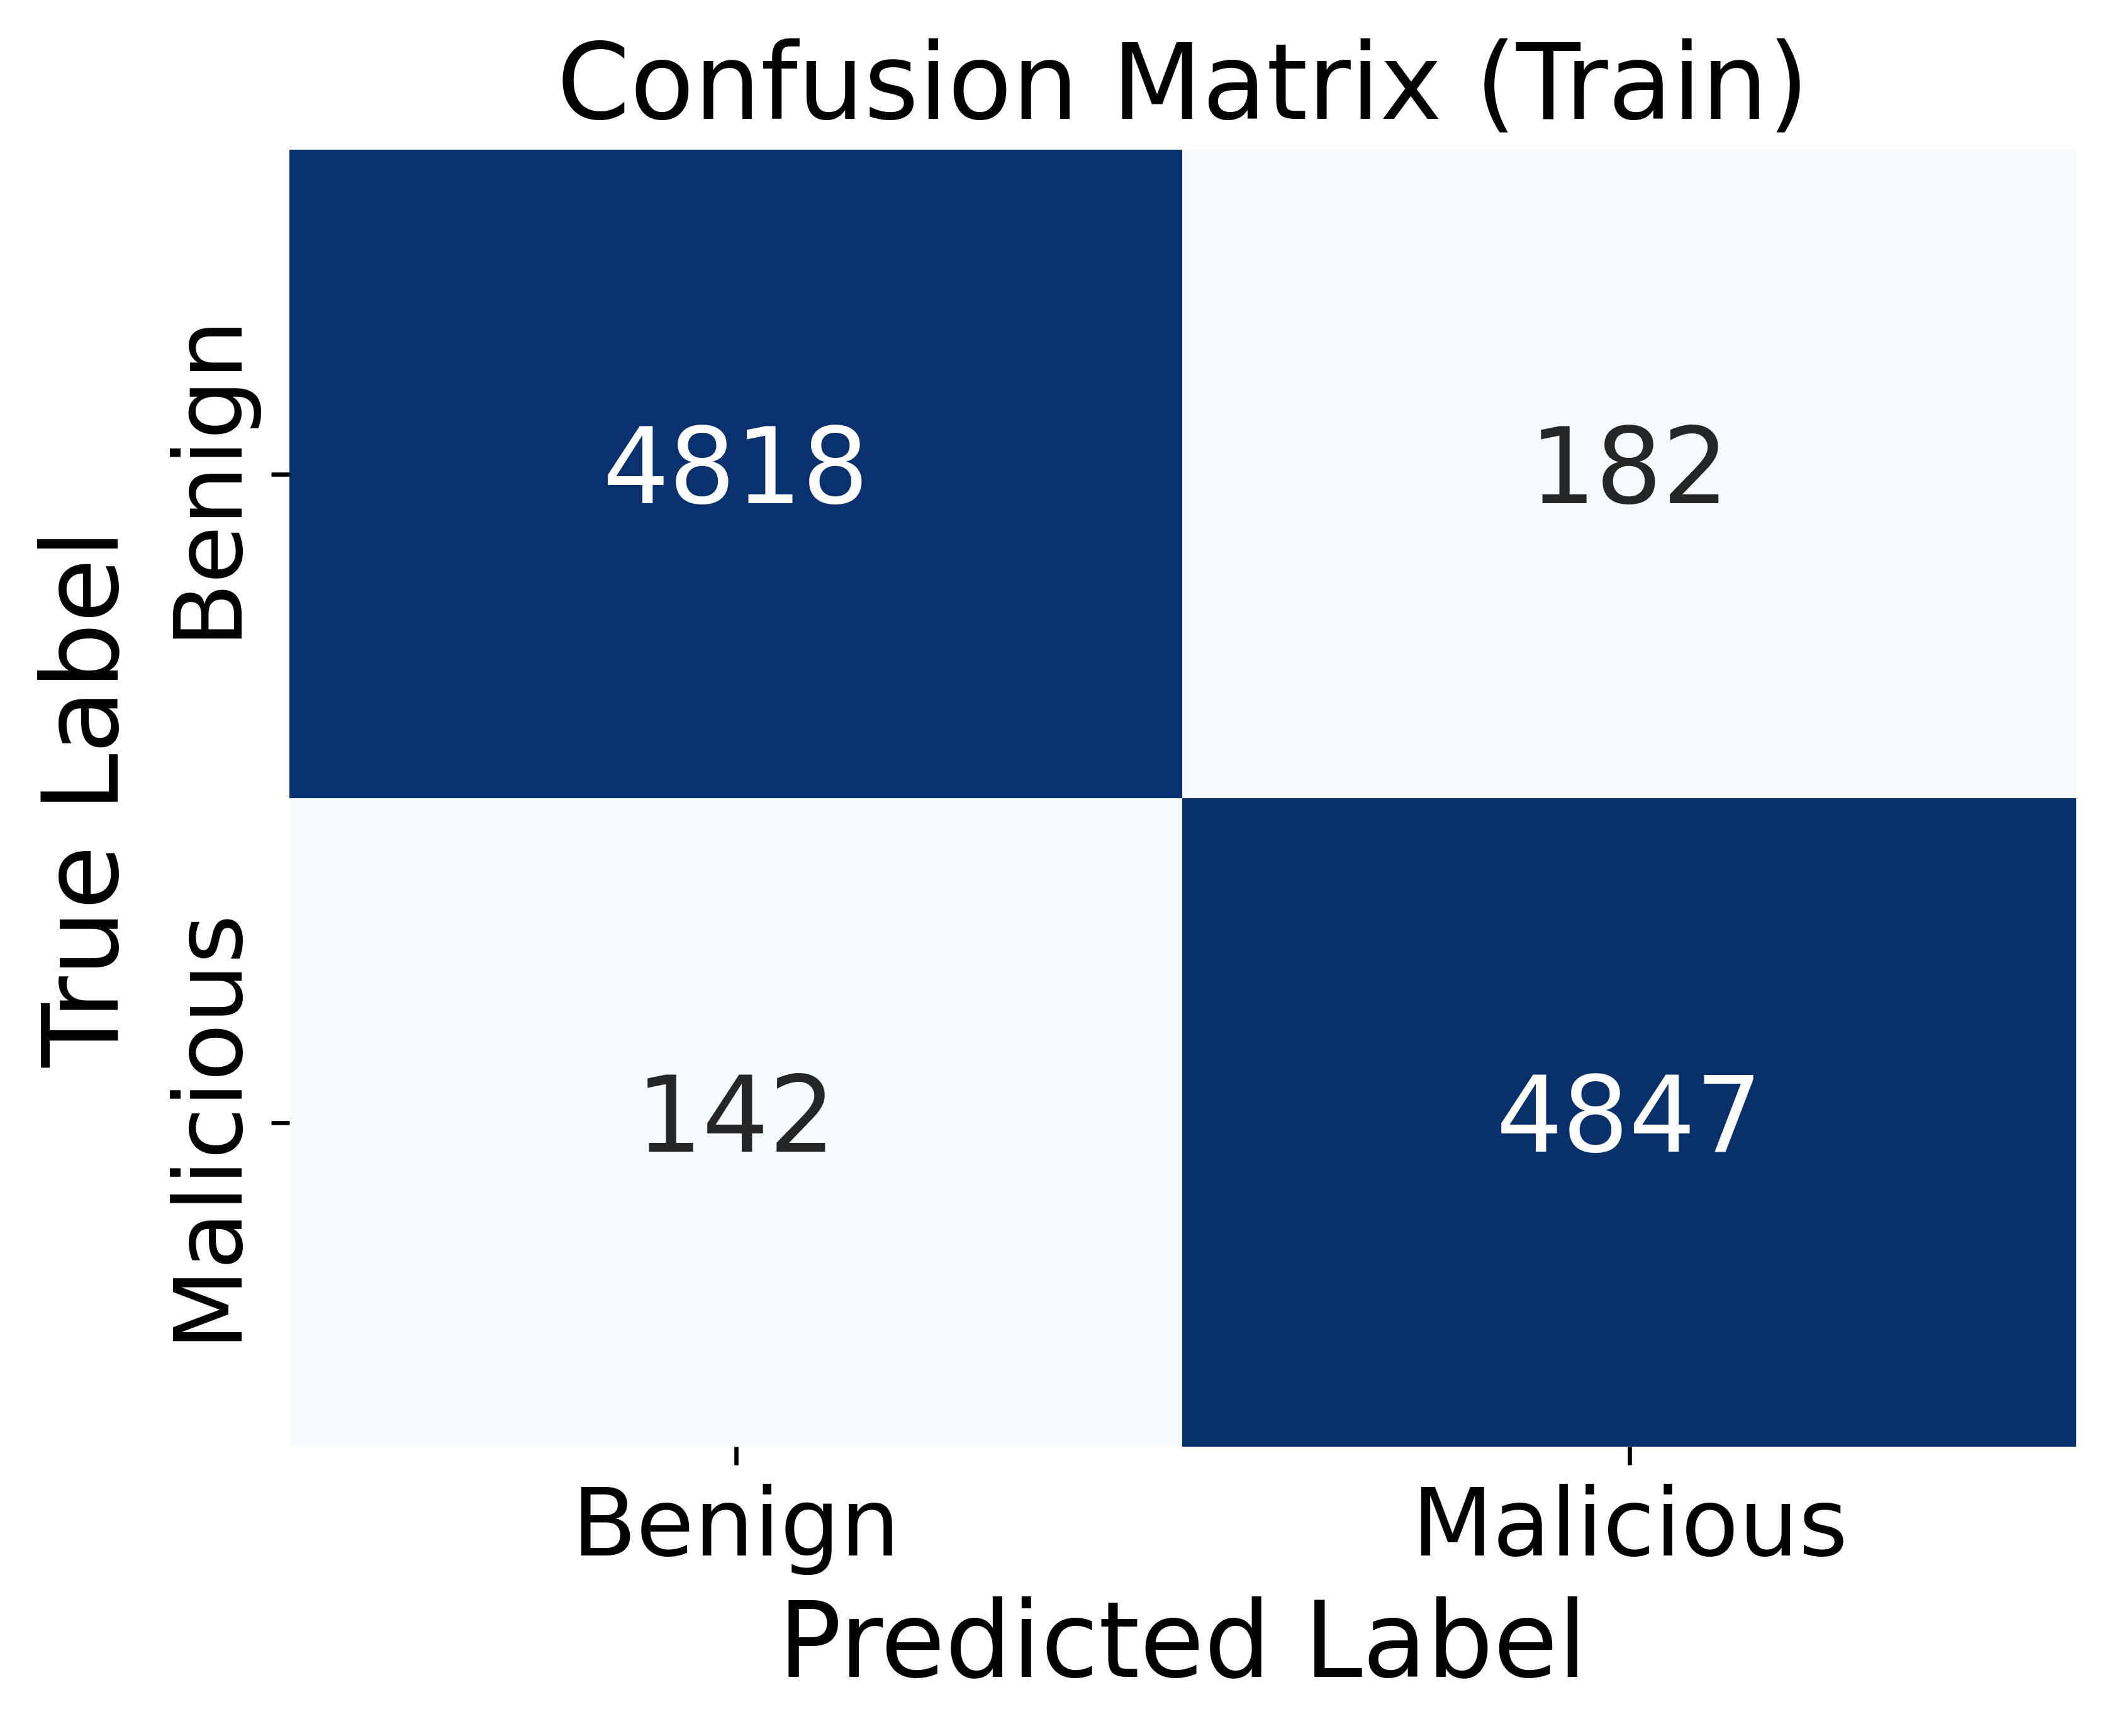

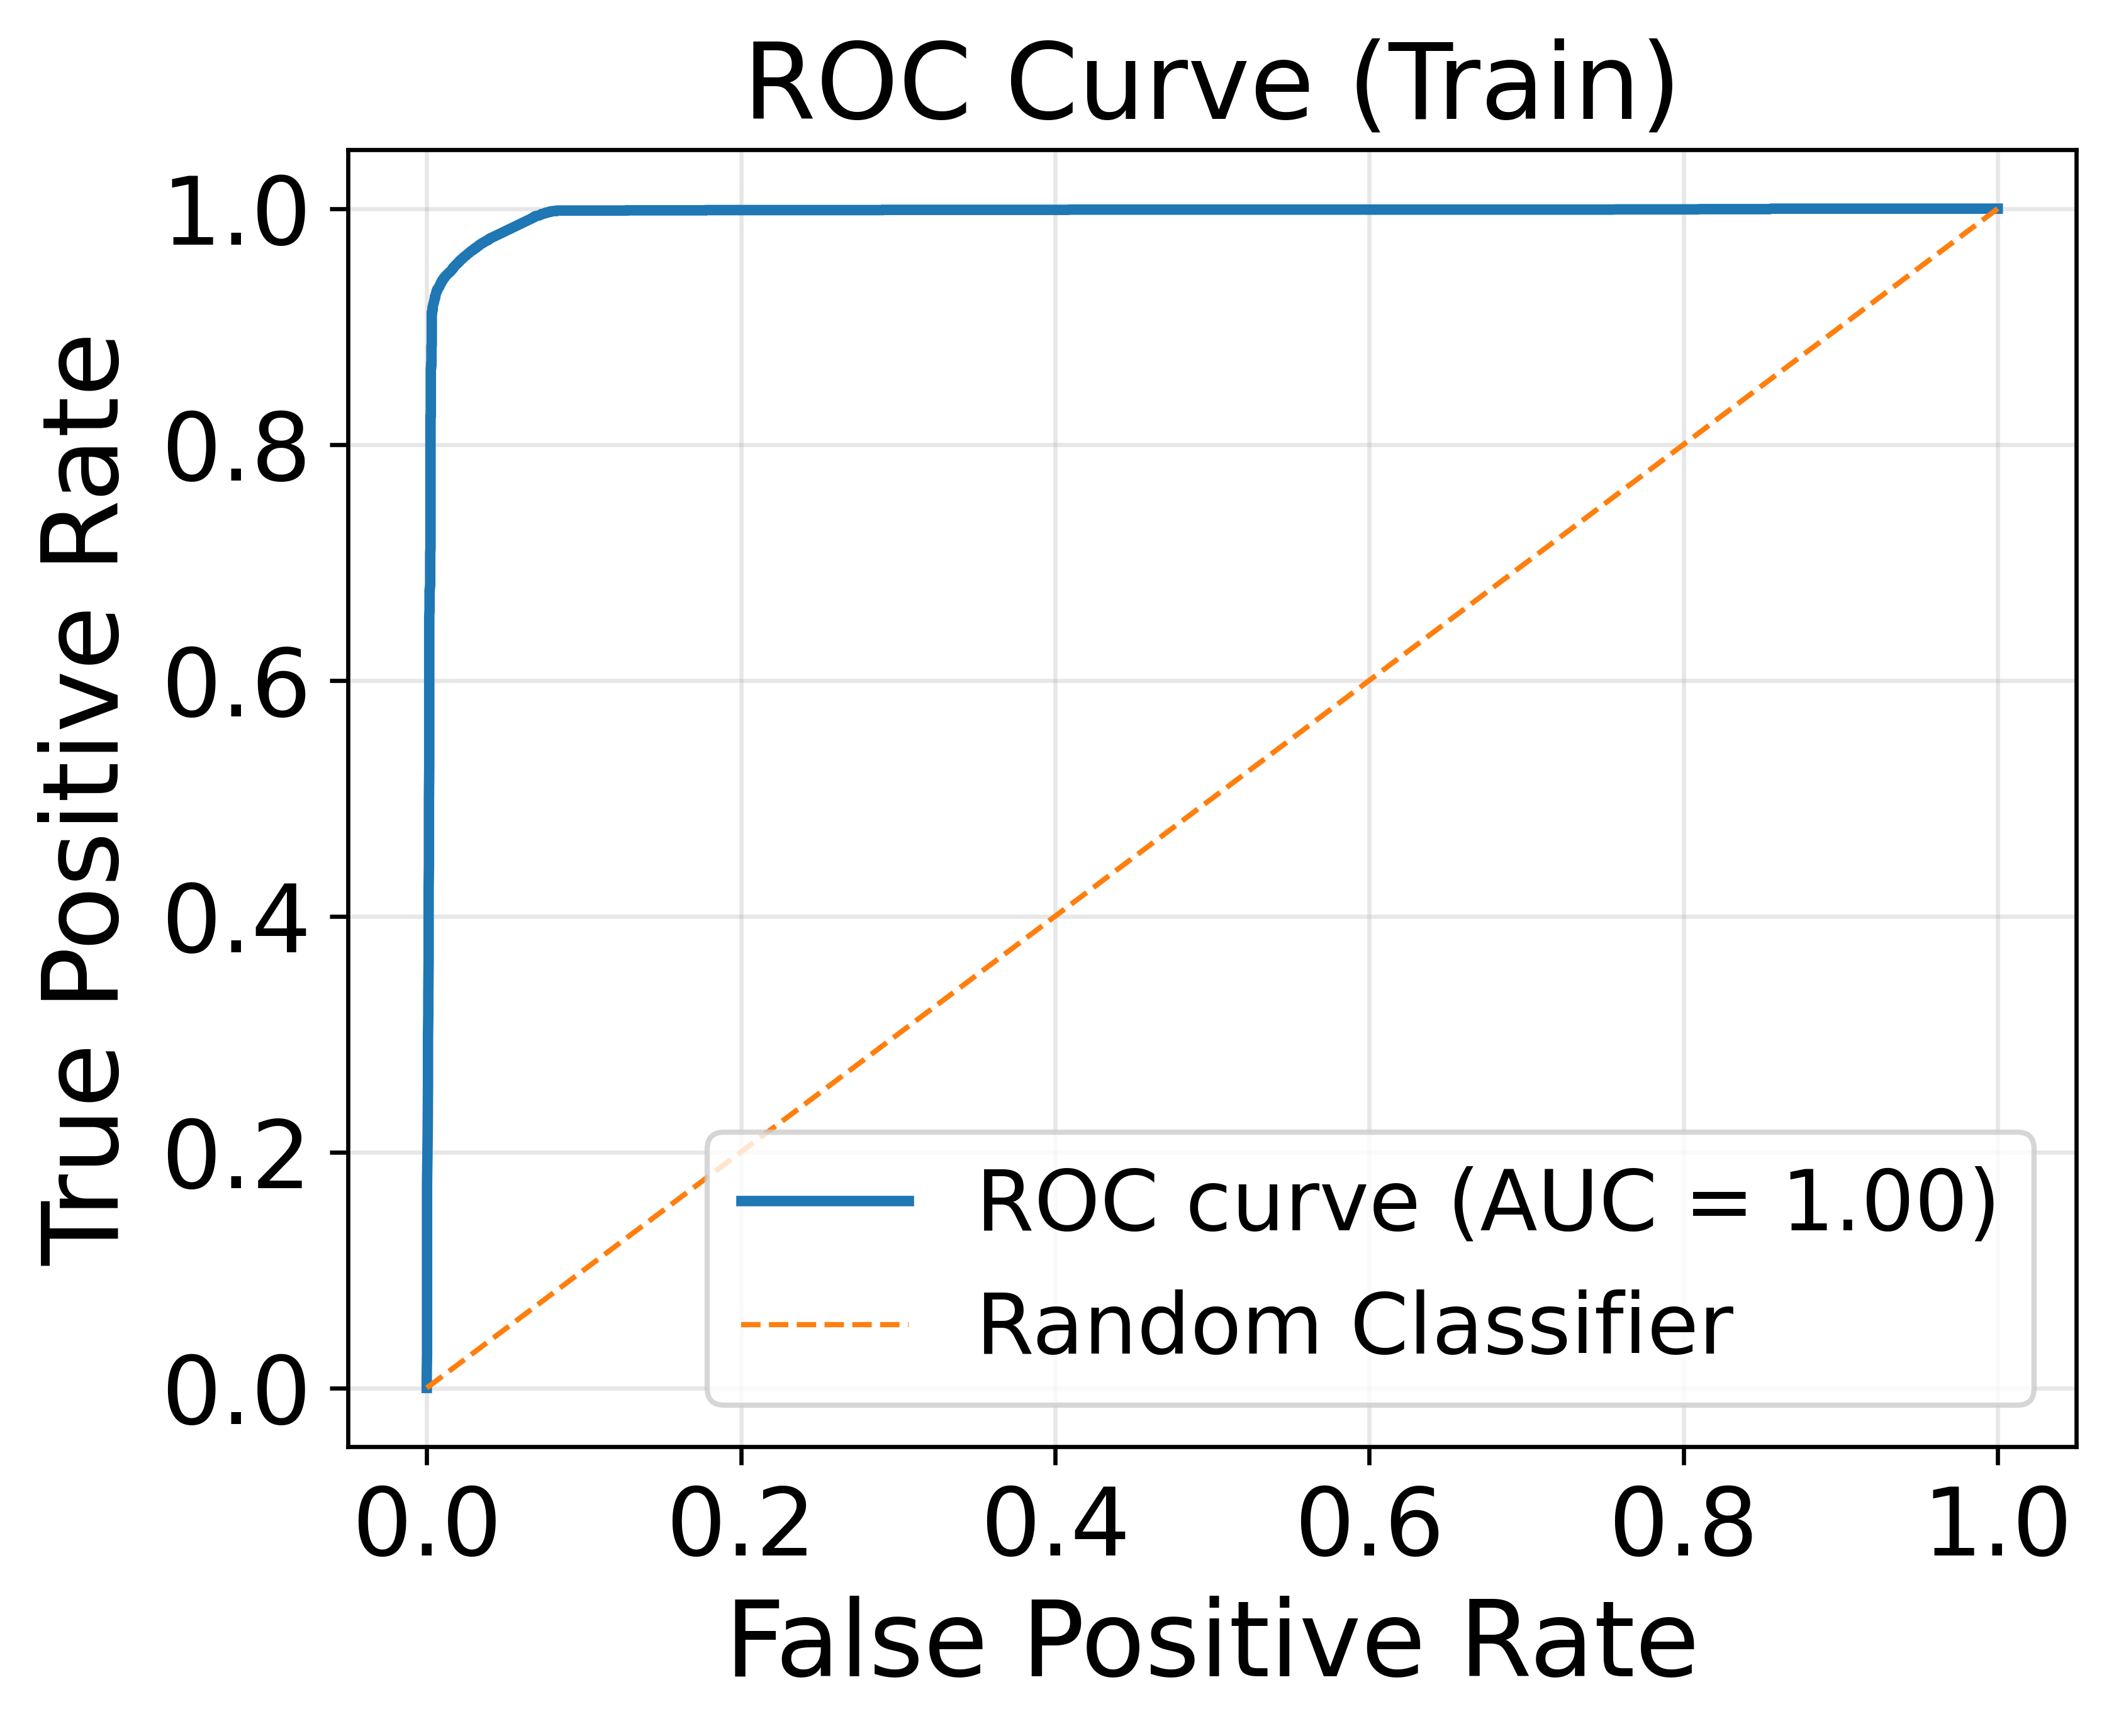


Evaluation Results: Validation
Accuracy  : 0.731901
Precision : 0.746760
Recall    : 0.700655
F1-score  : 0.722973
ROC AUC   : 0.808009
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.718805  0.763060  0.740271      1072
         1.0   0.746760  0.700655  0.722973      1069

    accuracy                       0.731901      2141
   macro avg   0.732782  0.731857  0.731622      2141
weighted avg   0.732763  0.731901  0.731634      2141



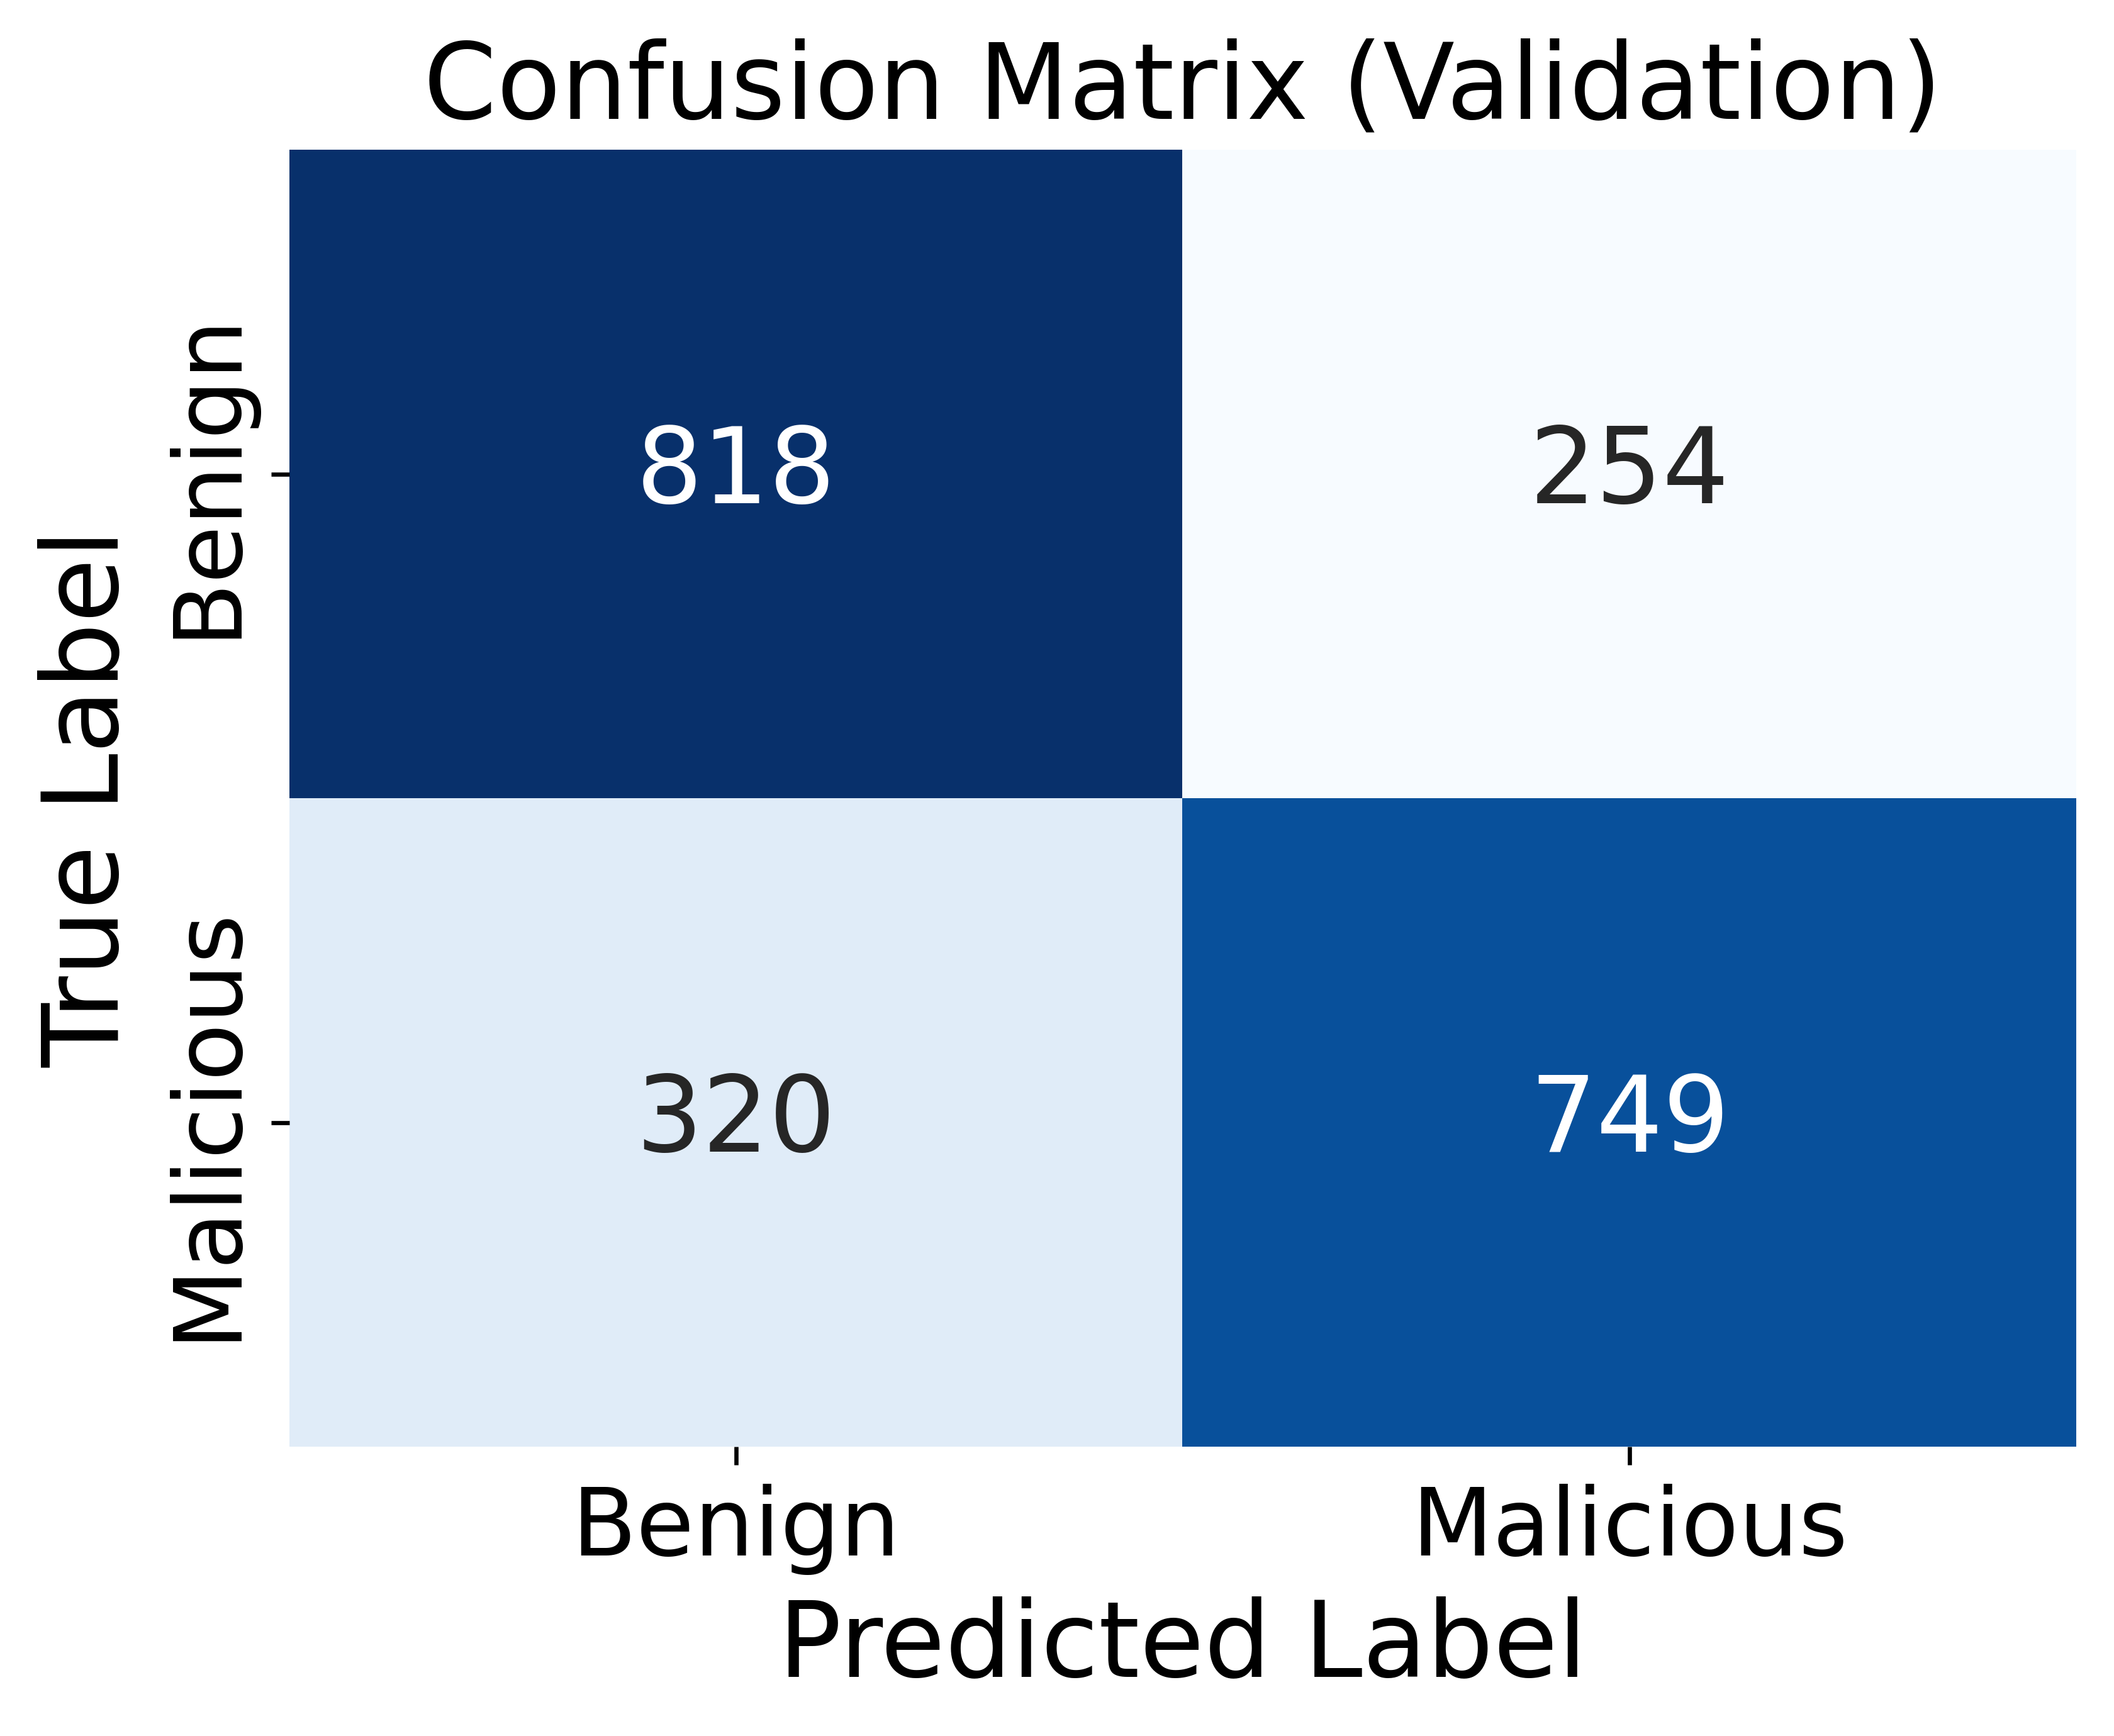

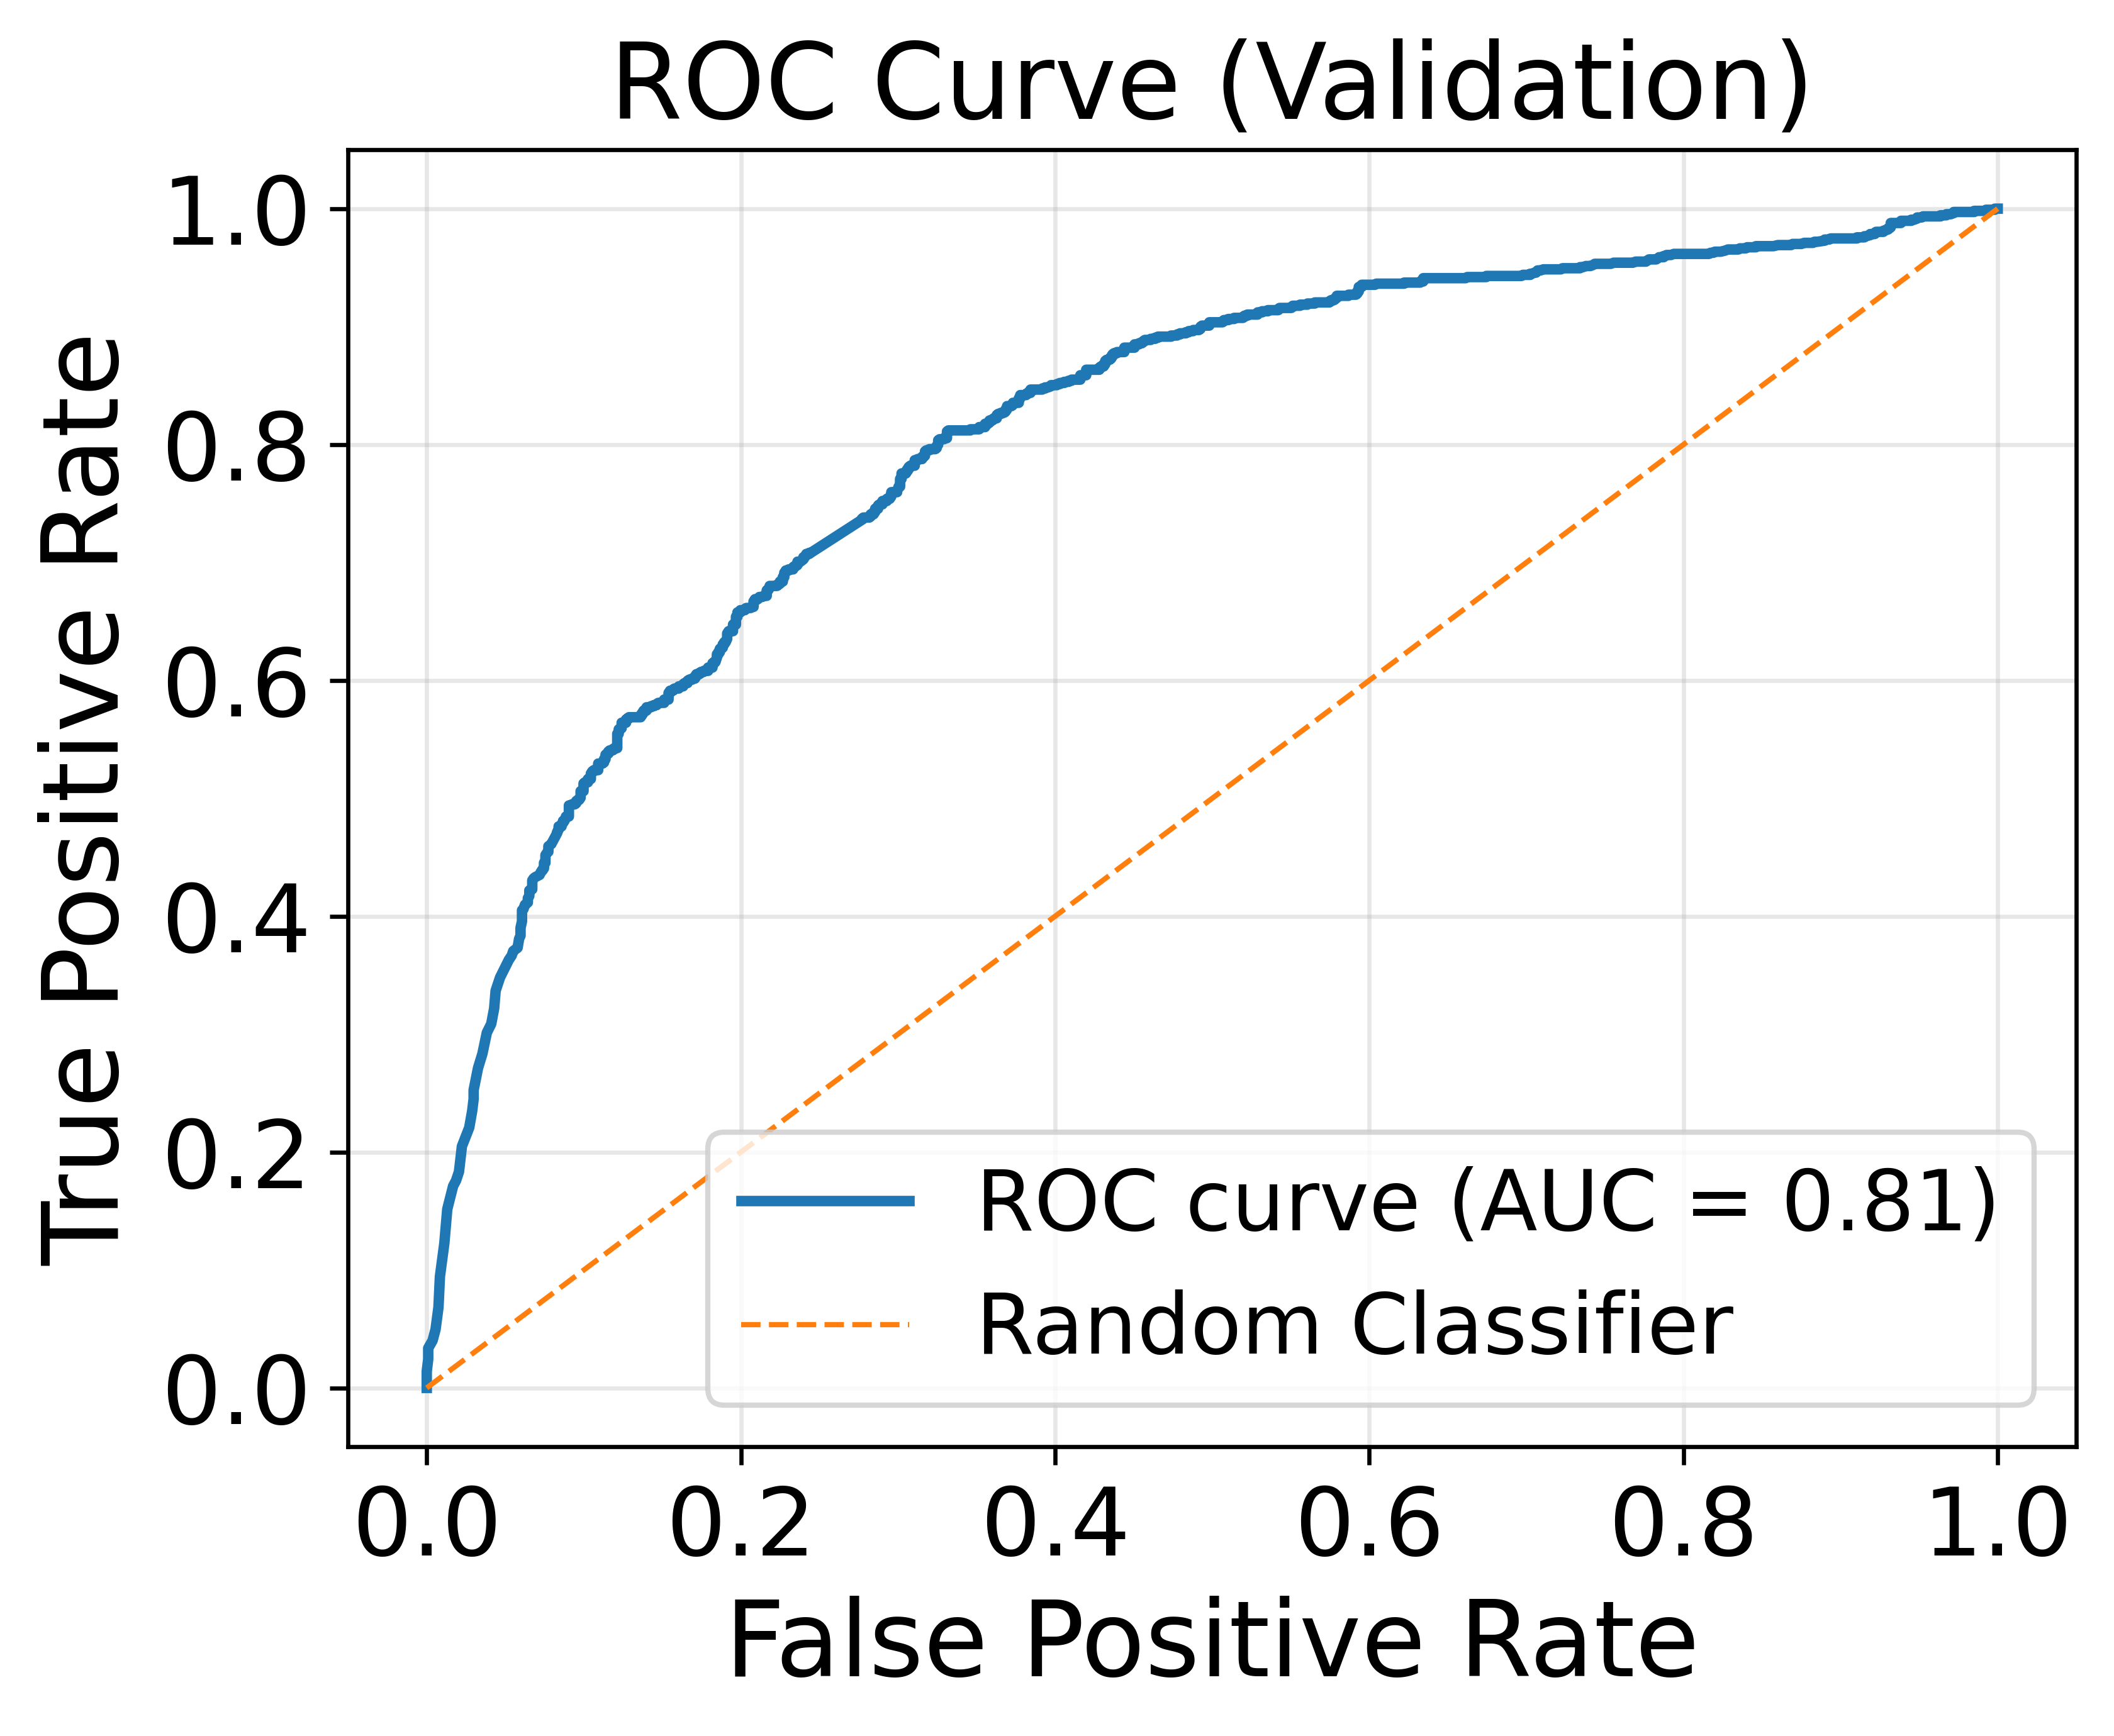


Evaluation Results: Test
Accuracy  : 0.760392
Precision : 0.779116
Recall    : 0.725912
F1-score  : 0.751574
ROC AUC   : 0.819537
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.744105  0.794776  0.768606      1072
         1.0   0.779116  0.725912  0.751574      1069

    accuracy                       0.760392      2141
   macro avg   0.761611  0.760344  0.760090      2141
weighted avg   0.761586  0.760392  0.760102      2141



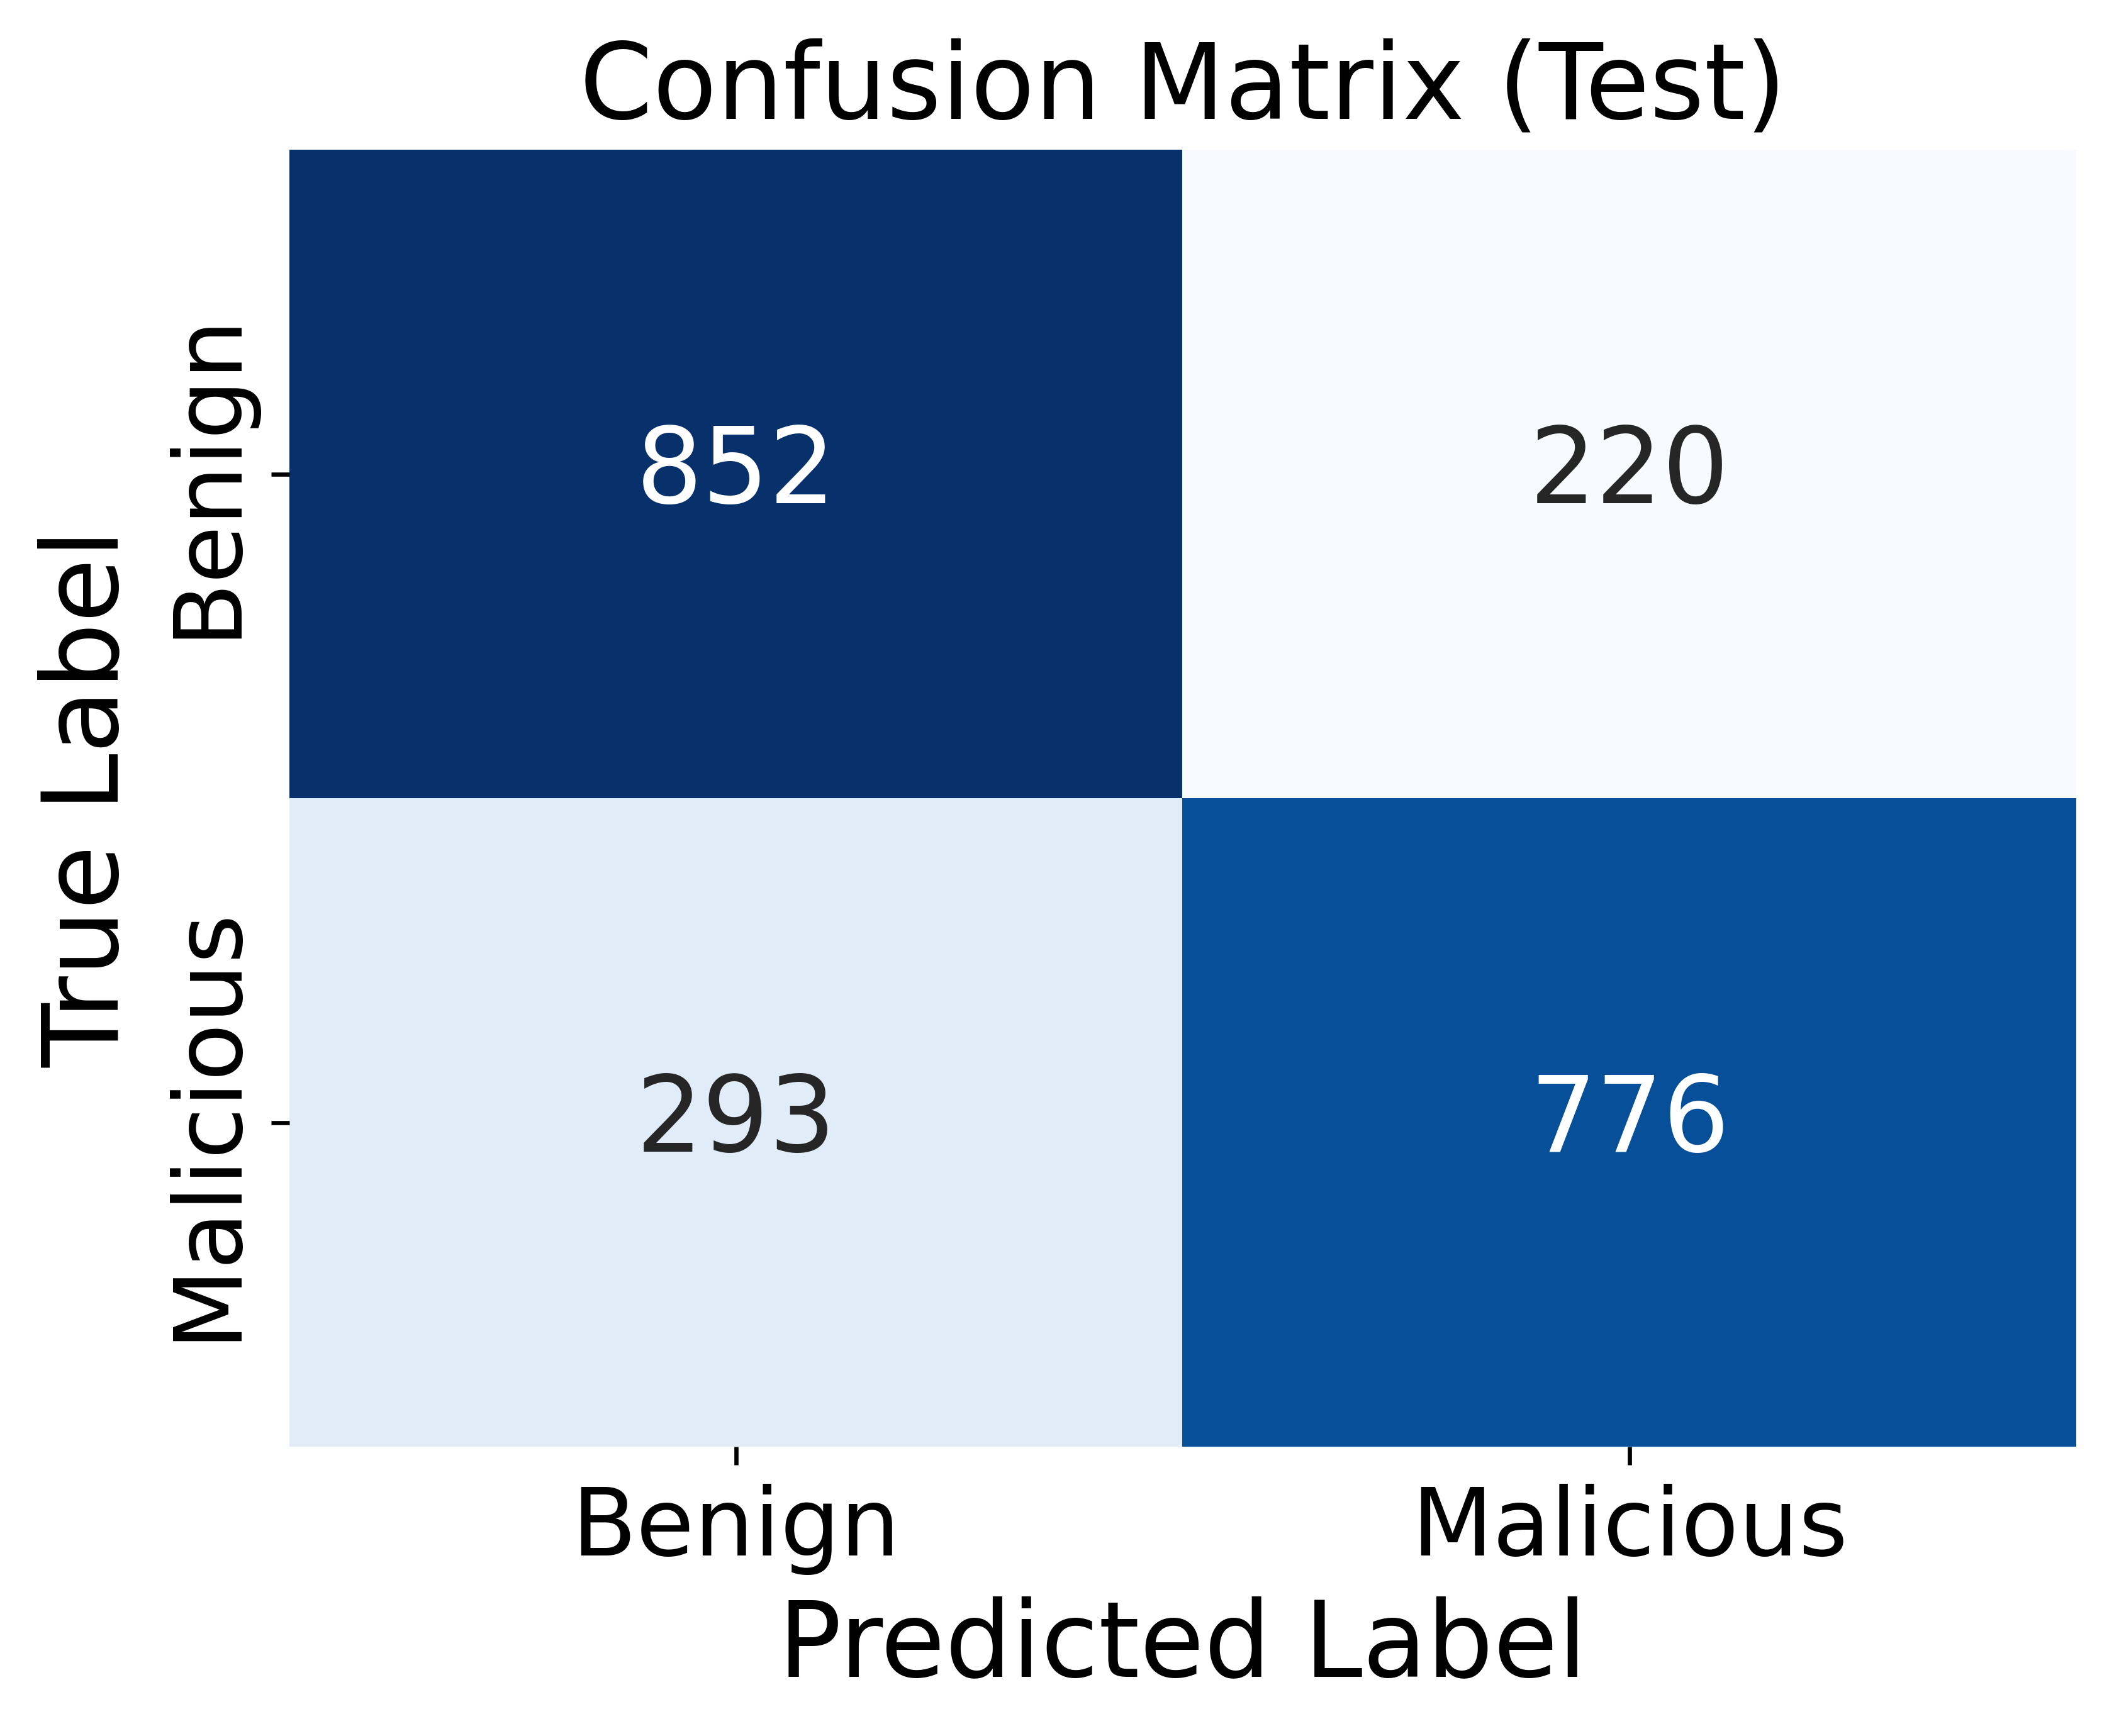

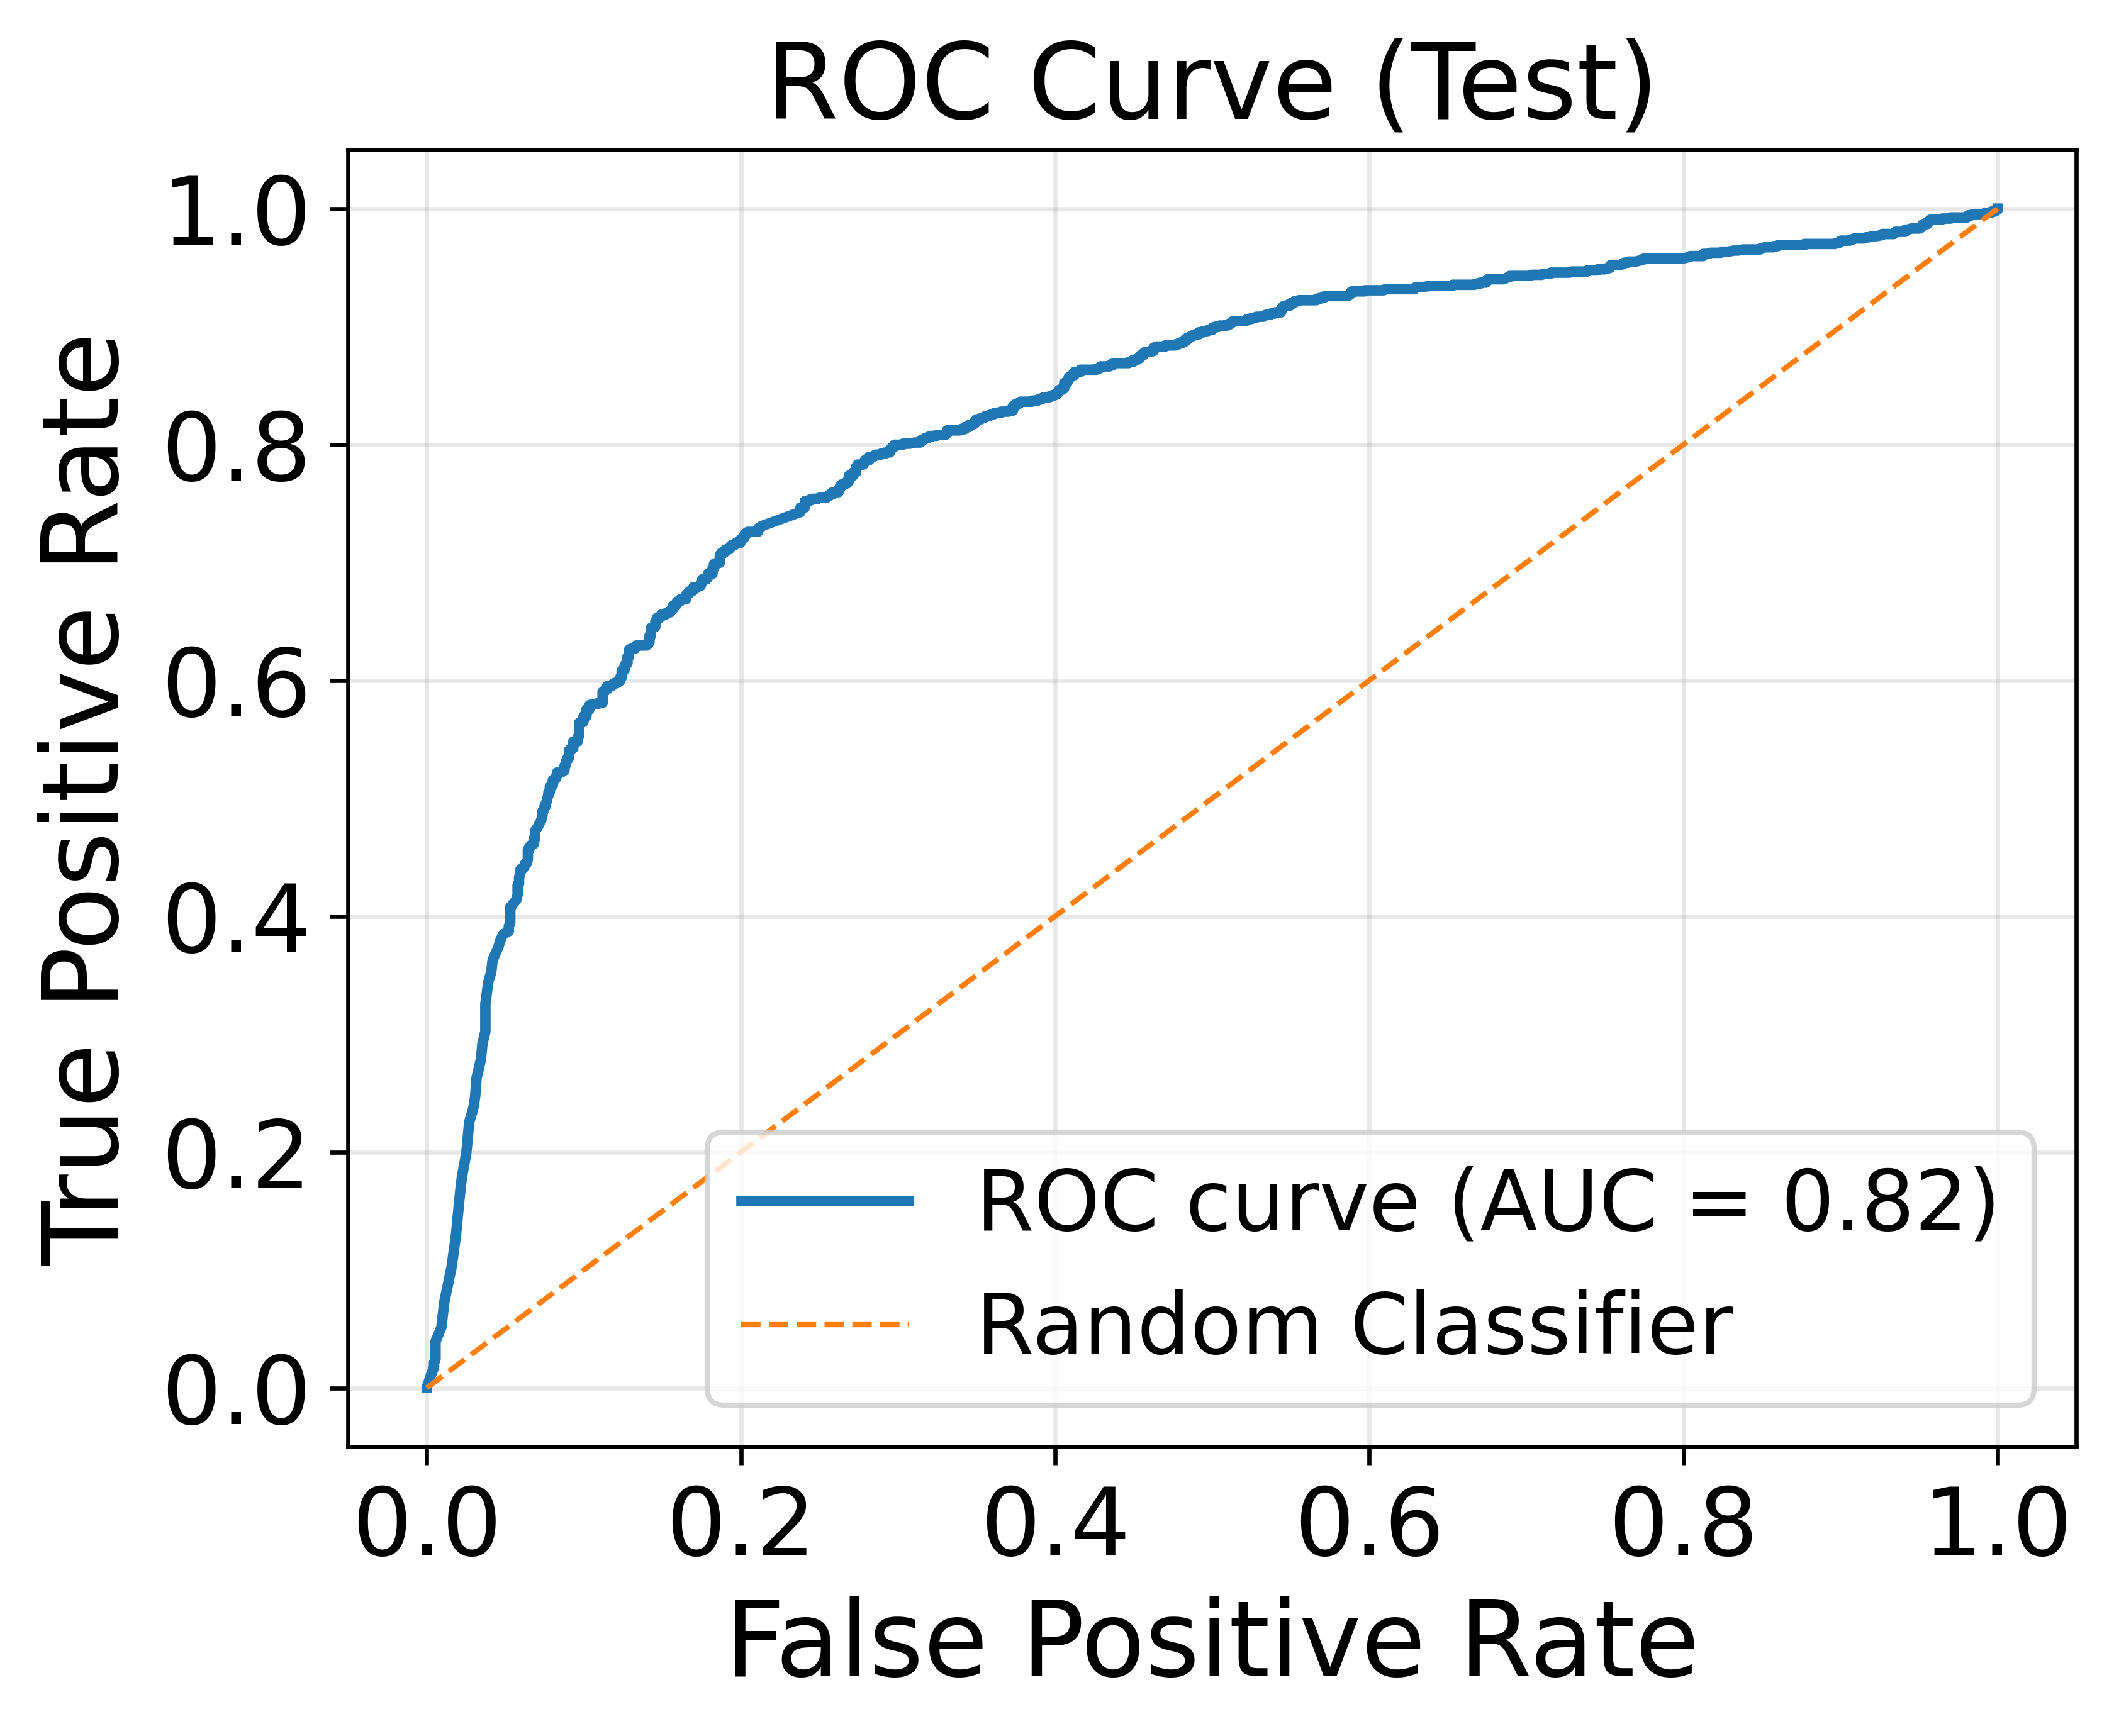

In [13]:
def evaluate_and_plot(model, encodings, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"])
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, y_test, "Test")

### Save All Results

In [14]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_TCP_PSO_Attention_BERT\evaluation_summary.csv
Excel: Evaluation_Outputs_TCP_PSO_Attention_BERT\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.967564,0.963810,0.971537,0.967658,0.995524
1,Validation,0.731901,0.746760,0.700655,0.722973,0.808009
2,Test,0.760392,0.779116,0.725912,0.751574,0.819537


### Clear Final Backend Session

In [15]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()